# Organizacion de datos
---
## <center> Trabajo Práctico 1

### <center> Ejercicio 4 - Agrupamiento (Clustering)

#### Grupo 05
| Integrante | Padron |
| :--- | :---: |
| Javier Zardain | 102521 |
| Bruno Pezman | 110457  |
| Malena Sein | 112295 |
| Candela Piccin | 109760 |
| Alexis Maximiliano Torres Vargas | 111449 |


---

### Bibliografía

Spotify *for developers*: https://developer.spotify.com/documentation/web-api/reference/get-several-audio-features

---

### Importamos librerias a utilizar

In [ ]:
#Manipulación y análisis de datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Visualizacion de los datos
import numpy as np
from sklearn.decomposition import PCA

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import random

---

### Descargamos el dataset

In [ ]:
!gdown 1fqrf525LqEMNuSwKLziET1YqwlknQ1OC

Downloading...
From: https://drive.google.com/uc?id=1fqrf525LqEMNuSwKLziET1YqwlknQ1OC
To: /content/playlist_spotify.csv
100% 54.4k/54.4k [00:00<00:00, 45.3MB/s]


---

### Analisis exploratorio

In [ ]:
df_spotify = pd.read_csv('playlist_spotify.csv')
df_spotify

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0.713000,0.514,100125,0.521,0.816000,8,0.1120,-14.835,0,0.0444,119.879,4,0.143
1,0.192000,0.714,207019,0.614,0.000000,4,0.2630,-6.935,1,0.0319,123.969,4,0.582
2,0.333000,0.630,216200,0.455,0.000004,5,0.1270,-9.290,1,0.0292,139.931,4,0.199
3,0.601000,0.810,136413,0.221,0.210000,5,0.1840,-11.005,1,0.0429,109.960,4,0.798
4,0.883000,0.465,181440,0.459,0.000173,6,0.0692,-8.137,0,0.0351,90.807,4,0.288
...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.000175,0.374,333827,0.943,0.000156,6,0.1250,-4.108,0,0.0556,112.084,4,0.338
746,0.001970,0.487,213000,0.867,0.006020,10,0.0968,-3.293,0,0.0543,160.048,4,0.403
747,0.916000,0.605,125867,0.314,0.000000,0,0.3590,-7.631,1,0.0327,138.148,4,0.836
748,0.168000,0.700,249493,0.823,0.000028,3,0.1220,-6.892,1,0.0373,144.060,4,0.745


| Variables | Descripción | Tipo |
|-----------|-------------|------|
| acousticness |  Medida de confianza (0.0 a 1.0)  de si la pista es acústica. | Cuantitativa Continua |
| danceabiity | Qué tan adecuada es una pista para bailar basándose en tempo, ritmo, fuerza del pulso y regularidad. | Cuantitativa Continua |
| duration | La duración de la pista expresada en milisegundos. | Cuantitativa Continua |
| energy | Medida perceptiva de intensidad y actividad. Valores entre 0.0 y 1.0, siendo 1.0 la mas energética. | Cuantitativa Continua |
| instrumentalness | Predice si la pista no tiene voces. Valores cercanos a 1.0 indican que es instrumental. | Cuantitativa Continua |
| key | Los números mapean a notas usando notación estándar de clase de tono (0 = Do, 1 = Do#, etc.). -1 indica que no se detectó. | Cualitativa Ordinal |
| liveness | Detecta la presencia de audiencia en la grabación. | Cuantitativa Continua |
| loudness | El volumen promedio de la pista en decibeles (dB). El rango de valores se encuentra tipicamente entre -60 Db y 0 Db.| Cuantitativa Continua |
| mode | Indica la modalidad (mayor o menor) de la escala. El modo Mayor es 1 y el Menor es 0. | Cualitativa Nominal |
| speechiness | Detecta palabras habladas. De 0.0 a 1.0 | Cuantitativa Continua |
| tempo | La velocidad o ritmo estimado de la pieza en BPM (Beats Per Minute) | Cuantitativa Continua |
| time_signature | Estimación de cuántos pulsos hay en cada compás. Rango de 3 a 7. | Cualitativa nominal|
| valence | Medida de la positividad musical. Valores altos suenan alegres o eufóricos. Rango entre 0.0 y 1.0 | Cuantitativa Continua |

In [ ]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      750 non-null    float64
 1   danceability      750 non-null    float64
 2   duration          750 non-null    int64  
 3   energy            750 non-null    float64
 4   instrumentalness  750 non-null    float64
 5   key               750 non-null    int64  
 6   liveness          750 non-null    float64
 7   loudness          750 non-null    float64
 8   mode              750 non-null    int64  
 9   speechiness       750 non-null    float64
 10  tempo             750 non-null    float64
 11  time_signature    750 non-null    int64  
 12  valence           750 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 76.3 KB


In [ ]:
df_spotify.isnull().sum().sum()

np.int64(0)

Podemos afirmar que no hay presencia de valores nulos por lo que no va a hacer necesario realizar ninguna estrategia para imputarlos o eliminarlos. Prosigamos viendo si los valores de los datos se encuentran dentro del dominio segun la bibliografía presentada.

Observemos las cualitativas:

In [ ]:
cualitativas = ['mode', 'key', 'time_signature']
lista_valores_dominio = []

for col in cualitativas:
    valores_dominio = ", ".join(map(str, df_spotify[col].unique()))
    lista_valores_dominio.append(valores_dominio)

df_cualitativas = pd.DataFrame({'Columna': cualitativas, 'Valores del dominio': lista_valores_dominio})
display(df_cualitativas)

,Columna,Valores del dominio
0,mode,"0, 1"
1,key,"8, 4, 5, 6, 9, 1, 0, 2, 7, 11, 3, 10"
2,time_signature,"4, 3, 5, 1"


In [ ]:
print(df_spotify['time_signature'].value_counts())

time_signature
4    671
3     64
5      9
1      6
Name: count, dtype: int64


Se decidió categorizar la variable *time_signature* como cualitativa nominal basándose en los siguientes criterios técnicos:
- Ausencia de Linealidad y Escala: Aunque se representa numéricamente (ej. 3, 4, 5), estos valores funcionan como etiquetas de categorías rítmicas. No existe una relación de orden o magnitud real; un compás de 4/4 no es "superior" a uno de 3/4, ni la "distancia" entre ellos tiene un significado físico que el algoritmo deba promediar.
- Prevención de Sesgo en el Modelo: Al tratarla como cuantitativa, el escalado le asignaría un peso artificial basado en su varianza. Dado que la gran mayoría de las canciones comerciales operan en 4/4, cualquier otra firma rítmica sería interpretada erróneamente por K-Means como un outlier extremo, alejando esas canciones de sus clusters naturales solo por una diferencia de compás.

Sabemos que los valores de *time_signature* se encuentran entre 3 y 7 segun la bibliografia, por lo que hay 6 columnas con valor 1 que se encuentran por fuera del dominio. Antes de borrarlos, investiguemos que podrian estar representando:

In [ ]:
# Filtramos los casos con time_signature == 1
valores_fuera_de_dominio = df_spotify[df_spotify['time_signature'] == 1]

# Seleccionamos columnas clave para el diagnóstico
columnas_diagnostico = ['duration', 'speechiness', 'acousticness', 'danceability', 'tempo']

print("Análisis de registros con time_signature = 1:")
display(valores_fuera_de_dominio[columnas_diagnostico])

# También podemos ver el promedio de estas variables comparado con el resto del dataset
print("\nPromedios del dataset completo para comparar:")
display(df_spotify[columnas_diagnostico].mean())

Análisis de registros con time_signature = 1:


,duration,speechiness,acousticness,danceability,tempo
54,208467,0.0283,0.04690,0.311,65.090
83,208467,0.0283,0.04690,0.311,65.090
316,312400,0.0409,0.92300,0.173,71.746
433,111304,0.0820,0.14400,0.904,138.084
502,215110,0.0598,0.00216,0.442,108.288
593,261107,0.0431,0.97700,0.350,144.171



Promedios del dataset completo para comparar:


,0
duration,220112.733333
speechiness,0.098966
acousticness,0.357394
danceability,0.596439
tempo,120.405761


Observaciones:
- Duplicación de errores: Los registros 54 y 83 son idénticos.

- Extremos de Acousticness: Los registros 316 y 593 tienen valores de acousticness altísimos (0.92 y 0.97) con muy poca *danceability*. Son probablemente grabaciones ambientales.

- Inconsistencia Rítmica: El registro 433 tiene una *danceability* de 0.90, pero un *time_signature* de 1. Esto es una contradicción técnica: es casi imposible que algo sea altamente bailable si no tiene un compás definido.

Como conclusión, conviene eliminarlos ya que representan apenas el 0.8% de la muestra (6 de 750). En clustering, mantener estos valores atípicos forzará a algoritmos como K-Means a desplazar los centroides para intentar abarcarlos, o peor aún, terminar con un cluster de solo 6 canciones que no aporta información útil al análisis general.


In [ ]:
df_spotify_clean = df_spotify[
    (df_spotify['time_signature'] >= 3) &
    (df_spotify['time_signature'] <= 7)
]
df_spotify_clean = df_spotify_clean.reset_index(drop=True)
df_spotify_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      744 non-null    float64
 1   danceability      744 non-null    float64
 2   duration          744 non-null    int64  
 3   energy            744 non-null    float64
 4   instrumentalness  744 non-null    float64
 5   key               744 non-null    int64  
 6   liveness          744 non-null    float64
 7   loudness          744 non-null    float64
 8   mode              744 non-null    int64  
 9   speechiness       744 non-null    float64
 10  tempo             744 non-null    float64
 11  time_signature    744 non-null    int64  
 12  valence           744 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 75.7 KB


Vamos ahora con las cuantitativas:

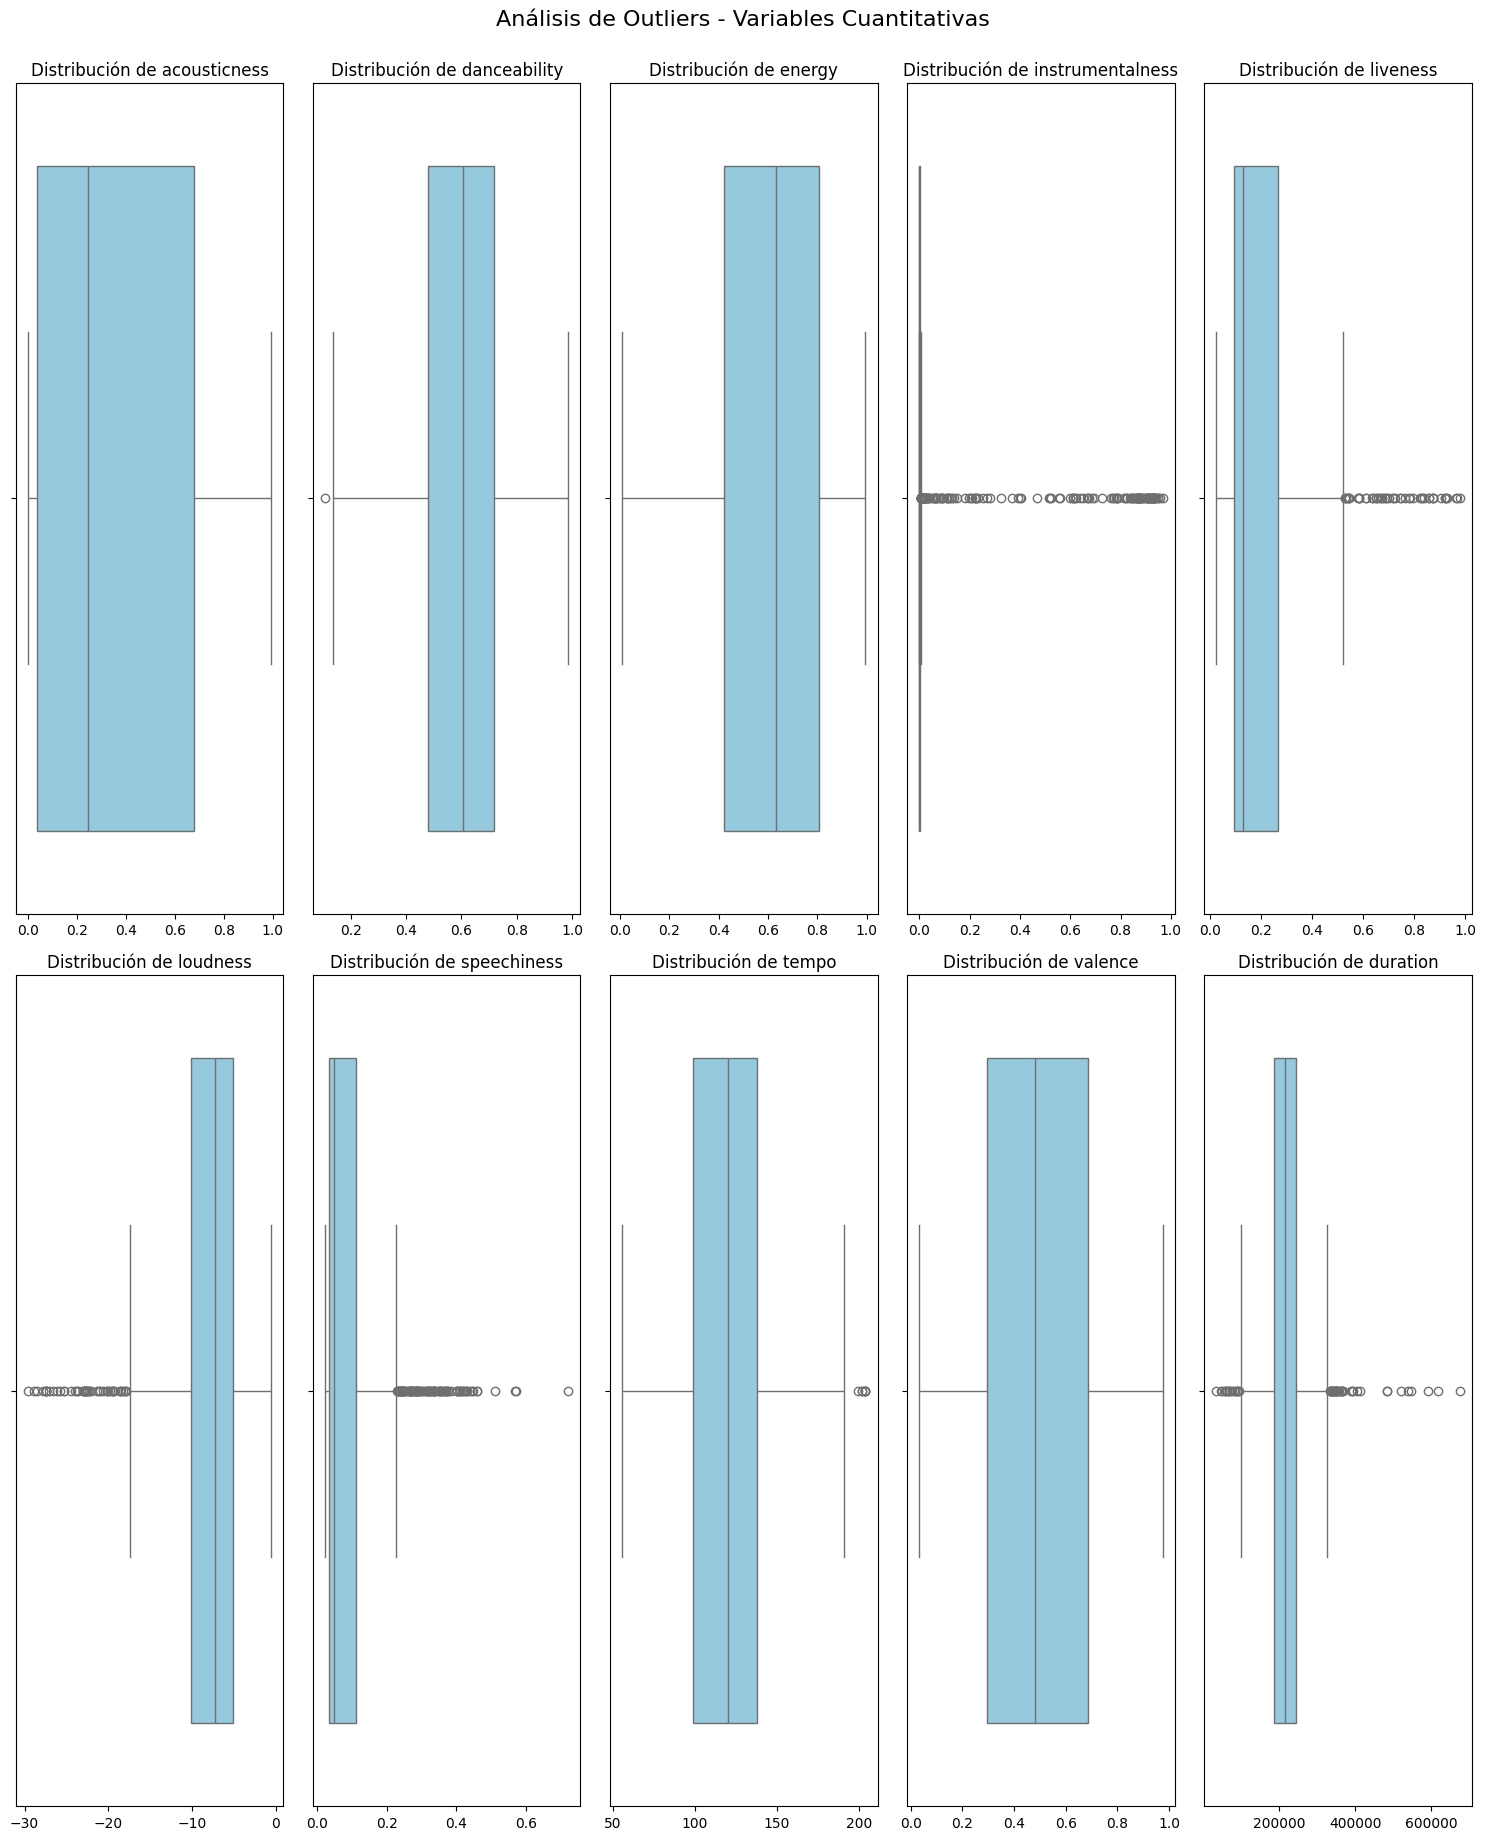

In [ ]:
# Lista completa de variables cuantitativas
cuantitativas = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence',
    'duration'
]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 18))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, col in enumerate(cuantitativas):
    sns.boxplot(x=df_spotify[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('') # Limpiamos el eje X para mayor claridad

# Eliminamos los subplots vacíos
if len(cuantitativas) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Análisis de Outliers - Variables Cuantitativas', fontsize=16, y=1.02)
plt.show()


Todos valores mostrados en los graficos son normales de encontrar en las canciones, inclusive los de *duration* dado que existen canciones con duracion mayor a 600.000ms.



---
### Analisis de la tendencia del dataset al clustering

Mediante el calculo de la Estadística de Hopkins mediremos la probabilidad de que un conjunto de datos sea generado por una distribución uniforme. El mismo compara la distancia entre puntos reales del dataset con la distancia entre puntos generados aleatoriamente.

In [ ]:
def hopkins(df, random_state=42):
    """
    Calcula el estadístico de Hopkins para un dataset.
    H aprox 0.5: Datos aleatorios.
    H cercano a 1.0: Alta tendencia al clustering.
    """
    np.random.seed(random_state)
    X = df.values
    n, d = X.shape
    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # Tomar una muestra uniforme de n puntos de 'd'.
    rand_indices = np.random.choice(n, m, replace=False)
    # Para cada punto pi ∈ D, encuentre su vecino más cercano pj, luego
    # calcular la distancia entre pi y pj
    u_distances, _ = nbrs.kneighbors(X[rand_indices], n_neighbors=2)
    u_sum = np.sum(u_distances[:, 1])

    # Generar un conjunto de datos simulados extraído de una distribución uniforme aleatoria con n puntos
    # y la misma variación que el conjunto de datos reales original 'd'
    min_x = X.min(axis=0)
    max_x = X.max(axis=0)
    random_points = np.random.uniform(low=min_x, high=max_x, size=(m, d))

    # Calcular la distancia yi desde cada punto artificial hasta el punto de datos real más cercano
    # Para cada punto qi ∈ rand_points, encontrar su vecino más cercano qj en 'd', luego
    # calcular la distancia entre qi y qj
    w_distances, _ = nbrs.kneighbors(random_points, n_neighbors=1)
    w_sum = np.sum(w_distances)

    return w_sum / (w_sum + u_sum)

# Escalamos el dataset completo
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_spotify_clean[cuantitativas]))
h_score = hopkins(df_scaled, random_state=42)
print(f"Estadístico de Hopkins: {h_score:.4f}")

Estadístico de Hopkins: 0.7842


Notas técnicas:
- Usamos el objeto `NearestNeighbors`. Al hacer `.fit(df.values)`, el algoritmo construye una estructura de datos optimizada que permite encontrar distancias en un espacio de $N$ dimensiones de forma rápida.
- Pedimos `n_neighbors=2` porque, para los puntos reales, el vecino más cercano es el punto mismo (distancia 0). Necesitamos el segundo para tener la distancia al "otro" punto más cercano.
- Dado que el dataset contiene registros con duraciones atípicas que son representativos del dominio musical, el uso de MinMaxScaler habría comprimido la varianza de la mayoría de los datos, reduciendo la capacidad del algoritmo para distinguir matices entre canciones. El StandardScaler, al centrar los datos en la media y escalar según la unidad de varianza, permite mantener la influencia de los atributos con mayor dispersión sin que los valores extremos anulen la información del resto de las variables.

Resultado: H = 0.7842

Un valor de 0.7842 indica una clara tendencia al clustering. Procederemos a estimar el número de clusters.




---

### Estimar la cantidad de clusters: Regla del codo

Ahora que demostramos que los datos se pueden agrupar, estimaremos con al regla del codo en cuantos grupos podriamos agrupar los datos.

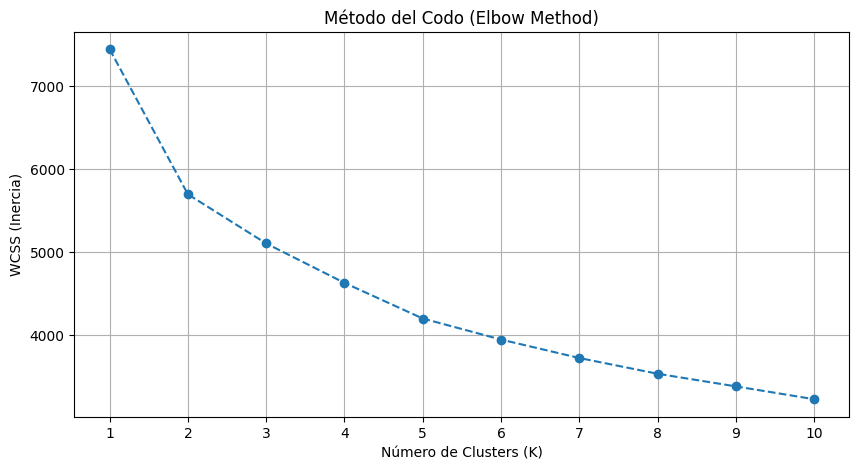

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_) # inertia_ es el WCSS en sklearn

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inercia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


Basandonos en el gráfico, observamos que a partir de k=2 se produce un quiebre pronunciado en la pendiente pero no podemos asegurar nada todavia. Veamos que ocurre si lo contrastamos con el análisis de Silhouette.

---

### Evaluar la calidad de los grupos: Análisis de Silhouette

Utilizaremos el análisis de Silhouette para definir K clusteres.

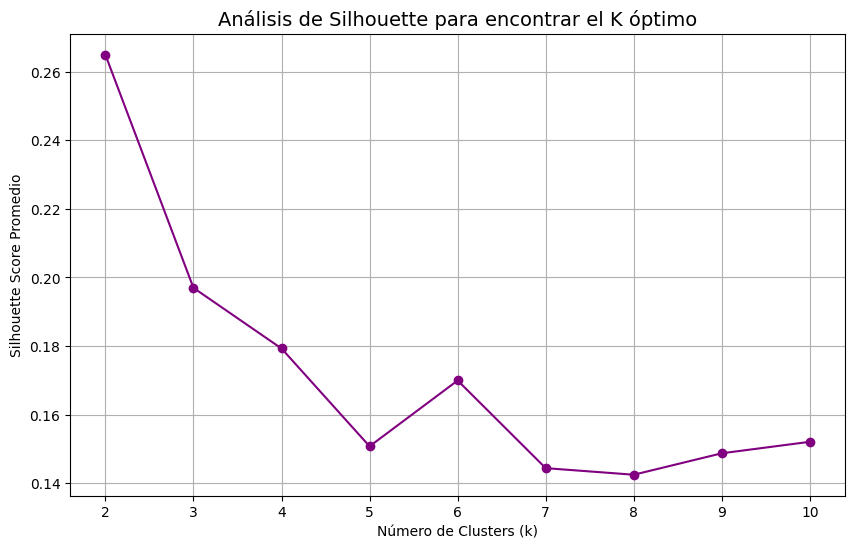

In [ ]:
range_n_clusters = range(2, 11)
silhouette_avg_list = []

for n_clusters in range_n_clusters:
    # Inicializamos KMeans
    clusterer = KMeans(n_clusters=n_clusters, random_state = 42)
    cluster_labels = clusterer.fit_predict(df_scaled)

    # Calculamos el score promedio
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_avg_list.append(silhouette_avg)
# Graficamos los resultados
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg_list, marker='o', color='purple')
plt.title('Análisis de Silhouette para encontrar el K óptimo', fontsize=14)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score Promedio')
plt.grid(True)
plt.show()


En el gráfico, podemos observar que en k=2 se maximiza el coeficente. El problema de esto es que al ser tan variada la cantidad de canciones, agruparlas en dos grupos puede llevarnos a una distinción trivial de temas con mayor energia y mas producidos, frente a otros con menos energia y mas acusticos. Veamos esta presunción en el siguiente analisis:

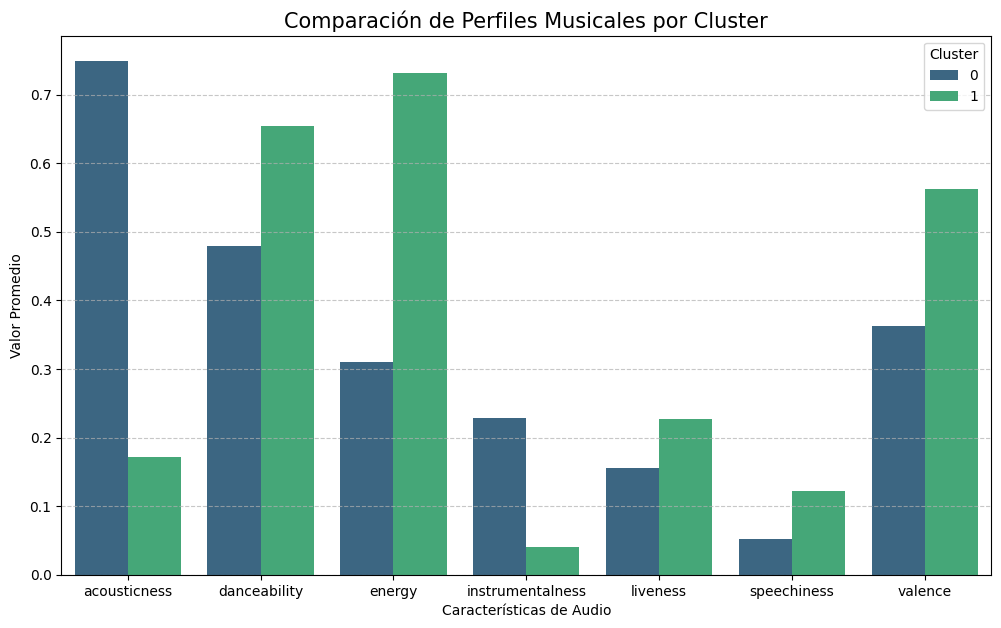

Diferencias en Tempo y Loudness:
              tempo   loudness
cluster                       
0        113.759594 -13.292912
1        123.808533  -6.212808


In [ ]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_labels = kmeans_final.fit_predict(df_scaled)
df_spotify_clean['cluster'] = clusters_labels

# Preparamos los datos: variables en rango [0, 1] para comparar perfiles
vars_comparacion = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                    'liveness', 'speechiness', 'valence']

resumen_proporcional = df_spotify_clean.groupby('cluster')[vars_comparacion].mean().reset_index()
resumen_melted = resumen_proporcional.melt(id_vars='cluster', var_name='Variable', value_name='Promedio')

# Creación del Gráfico de Barras Agrupadas
plt.figure(figsize=(12, 7))
sns.barplot(x='Variable', y='Promedio', hue='cluster', data=resumen_melted, palette='viridis')

plt.title('Comparación de Perfiles Musicales por Cluster', fontsize=15)
plt.ylabel('Valor Promedio')
plt.xlabel('Características de Audio')
plt.legend(title='Cluster')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Mención aparte para las variables de escala distinta
resumen_escalas = df_spotify_clean.groupby('cluster')[['tempo', 'loudness']].mean()
print("Diferencias en Tempo y Loudness:")
print(resumen_escalas)

Al analizar la composición de los grupos, se identifica una estructura bipolar clara que explica el valor del Estadístico de Hopkins (0.7842) :

- Cluster 0: *"Orgánicas y Minimalistas"*

  La variable dominante es la *Acousticness*, que actúa como el principal diferenciador. En este segmento, la energía y el volumen disminuyen drásticamente, dando lugar a una estructura mucho más espacial y pausada. El agrupamiento sugiere temas de corte orgánico, donde la fidelidad de los instrumentos naturales prevalece sobre el procesamiento digital.

- Cluster 1: *"Energéticas"*

  Este grupo está traccionado por una fuerte correlación positiva entre *Energy*, *Loudness* y *Danceability*. Son temas con una arquitectura sonora densa (baja *Acousticness*), diseñados para el movimiento y con un tempo elevado. El algoritmo agrupa aquí las producciones donde predomina la intensidad sobre la pureza instrumental.

Veamos esto mas gráfico con un Análisis de Componentes Principales (PCA) dado que la naturaleza de este metodo permite usar el eje X para distinguir la intensidad sonora entre clusters. Se observó que el Componente Principal 1 (PC1) explica la mayor parte de la varianza mediante la oposición entre variables de intensidad (energy, loudness) y variables de organicidad (acousticness).

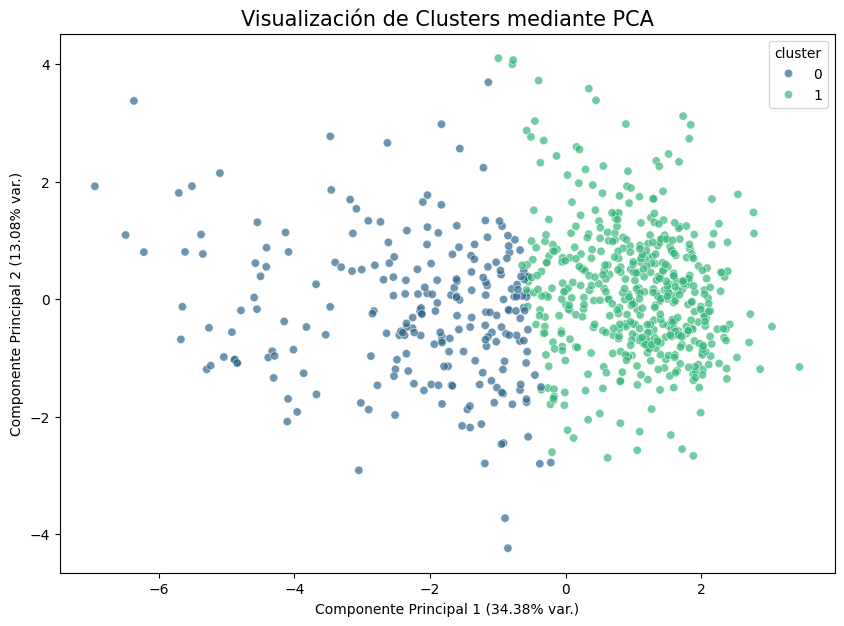

        PC1       PC2
0 -0.441834 -0.243774
1  0.338092 -0.432636
2  0.465333  0.275861
3 -0.284111  0.084807
4  0.104001  0.465718
5  0.466535  0.184873
6  0.193450 -0.097209
7  0.141039  0.074148
8  0.290535 -0.405203
9 -0.151740  0.489796


In [ ]:
# Reducimos a 2 dimensiones para poder graficar
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(df_scaled) # Usamos los datos escalados

# Creamos un DataFrame para graficar
df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_spotify_clean['cluster']

# Visualización
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Visualización de Clusters mediante PCA', fontsize=15)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} var.)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} var.)')
plt.show()

# Los "loadings" para saber qué variables forman cada componente
print(pd.DataFrame(pca.components_, columns=df_scaled.columns, index=['PC1', 'PC2']).T)

El Cluster 1 se identifica claramente como un grupo de alta intensidad sonora, caracterizado por canciones con mayor volumen, energía y aptas para el baile. Por el contrario, el Cluster 0 agrupa el contenido acústico e instrumental, presentando una mayor dispersión, lo que sugiere una mayor heterogeneidad dentro de este género. Dicha heterogeneidad puede implicar que dentro de ese grupo convivan subperfiles. Esto nos animó a utilizar $K = 3$. Veamos como se comporta el grafico de barras.

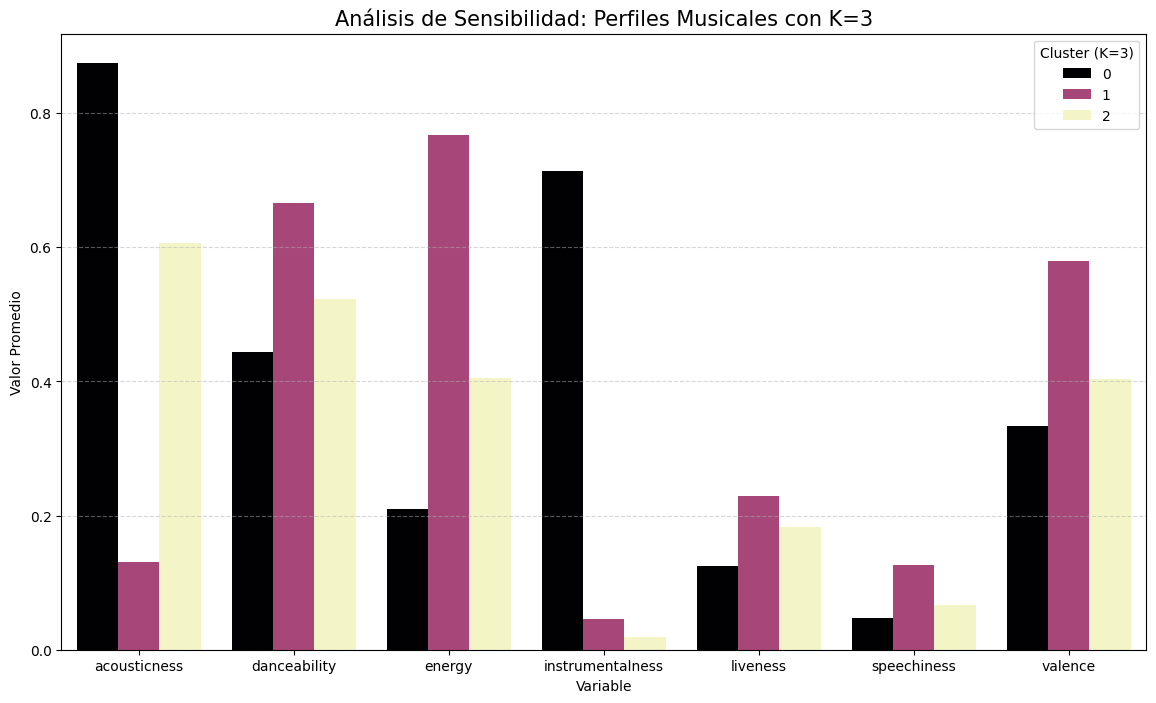

Diferencias en Tempo y Loudness (K=3):
                 tempo   loudness
cluster_k3                       
0           109.348225 -18.660000
1           124.622979  -5.724172
2           116.708835 -10.404198


In [ ]:
# Ejecutamos KMeans con K=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_spotify_clean['cluster_k3'] = kmeans_3.fit_predict(df_scaled)

# Preparamos los datos para el gráfico de barras
vars_comparacion = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                    'liveness', 'speechiness', 'valence']

resumen_k3 = df_spotify_clean.groupby('cluster_k3')[vars_comparacion].mean().reset_index()
resumen_melted_k3 = resumen_k3.melt(id_vars='cluster_k3', var_name='Variable', value_name='Promedio')

# Visualización de Perfiles
plt.figure(figsize=(14, 8))
sns.barplot(x='Variable', y='Promedio', hue='cluster_k3', data=resumen_melted_k3, palette='magma')

plt.title('Análisis de Sensibilidad: Perfiles Musicales con K=3', fontsize=15)
plt.ylabel('Valor Promedio')
plt.legend(title='Cluster (K=3)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Variables de escala distinta para K=3
print("Diferencias en Tempo y Loudness (K=3):")
print(df_spotify_clean.groupby('cluster_k3')[['tempo', 'loudness']].mean())

Observemos como ahora uno de los clusters presenta un valor de *instrumentalness* considerablemente mas elevado que las demás. Sumado a un nivel muy bajo de *speechiness* podemos relacionar este conjunto de temas al genero instrumental. Es decir, con $K=2$ observabamos un cluster que englobaba tanto a temas de jazz, country y generos similes como a piezas de musica clasica y de ambiente. Veamos como se ve el grafico con PCA ahora:

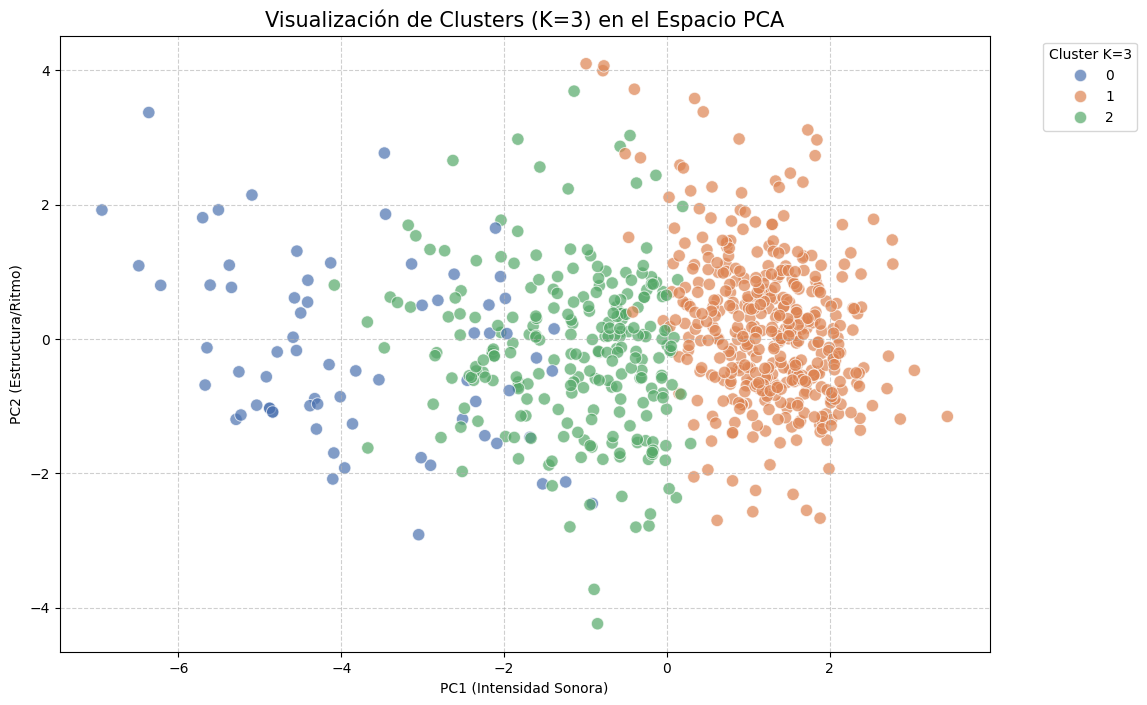

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['cluster_k3'] = df_spotify_clean['cluster_k3'].values

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster_k3',
    data=df_pca,
    palette='deep',
    alpha=0.7,
    edgecolor='w',
    s=80
)

plt.title('Visualización de Clusters (K=3) en el Espacio PCA', fontsize=15)
plt.xlabel(f'PC1 (Intensidad Sonora)')
plt.ylabel(f'PC2 (Estructura/Ritmo)')
plt.legend(title='Cluster K=3', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Finalmente, la visualización en el espacio de componentes principales para $K=3$ valida la hipótesis planteada: la varianza observada en el sector de menor intensidad sonora no era aleatoria, sino que respondía a una diferenciación clara entre canciones acústicas con presencia vocal y composiciones puramente instrumentales.

Mientras que el Cluster 1 captura la música de alta energía y producción como el pop, rock y la electronica, el modelo logra ahora subdividir el espectro orgánico. El Cluster 0 se caracteriza por una instrumentalness extrema y mínima energy, representando piezas atmosféricas o clásicas, mientras que el Cluster 2 agrupa el contenido de canciones con intensidad media, con voces presentes pero arreglos orgánicos (Indie, Jazz vocal, Acústicos tranquilos). Esta segmentación tripartita ofrece una resolución mucho más fiel a la diversidad del catálogo de Spotify analizado.